# Loss & WER 可视化（统一 iter）

将 CTC 与 ATT 的 loss/wer 统一到同一迭代尺度上（CTC 的 iter 比 ATT 多，这里以共同区间为横轴），再绘图对比。

In [6]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# CSV 与 notebook 同目录；若 kernel 在 project5-6 下跑，则用 'loss_wer'
LOG_DIR = '.'
if not os.path.isfile(os.path.join(LOG_DIR, 'run-asr_ctc_sd0_loss_tr_ctc-tag-loss.csv')):
    LOG_DIR = 'loss_wer'
print('Log dir:', os.path.abspath(LOG_DIR))

Log dir: /home/educate/Yihang/course_proj/CS304/CS304_Projects/project56/project5-6/loss_wer


In [7]:
# 加载 6 个 CSV（格式: Wall time, Step, Value）
def load_series(path):
    df = pd.read_csv(path)
    return df['Step'].values, df['Value'].values

files = {
    'loss_ctc': 'run-asr_ctc_sd0_loss_tr_ctc-tag-loss.csv',
    'loss_att': 'run-asr_att_sd0_loss_tr_att-tag-loss.csv',
    'wer_tr_ctc': 'run-asr_ctc_sd0_wer_tr_ctc-tag-wer.csv',
    'wer_tr_att': 'run-asr_att_sd0_wer_tr_att-tag-wer.csv',
    'wer_dv_ctc': 'run-asr_ctc_sd0_wer_dv_ctc-tag-wer.csv',
    'wer_dv_att': 'run-asr_att_sd0_wer_dv_att-tag-wer.csv',
}

data = {}
for key, fname in files.items():
    path = os.path.join(LOG_DIR, fname)
    if os.path.isfile(path):
        steps, vals = load_series(path)
        data[key] = (steps, vals)
        print(f"{key}: {len(steps)} points, step range [{steps.min()}, {steps.max()}]")
    else:
        print(f"Skip (not found): {path}")
print('\nLoaded keys:', list(data.keys()))

loss_ctc: 1000 points, step range [400, 919800]
loss_att: 1000 points, step range [400, 339000]
wer_tr_ctc: 1000 points, step range [400, 919800]
wer_tr_att: 1000 points, step range [400, 339000]
wer_dv_ctc: 184 points, step range [1, 915000]
wer_dv_att: 68 points, step range [1, 335000]

Loaded keys: ['loss_ctc', 'loss_att', 'wer_tr_ctc', 'wer_tr_att', 'wer_dv_ctc', 'wer_dv_att']


In [8]:
# 统一到同一 iter：取「所有序列都覆盖」的步数区间，再在均匀步长上插值
def to_common_grid(data_dict, step_interval=1000):
    """
    得到共同步数区间 [0, min_max_step]，再按 step_interval 生成网格，对每个序列线性插值。
    """
    min_max = min(np.max(s) for s, v in data_dict.values())
    max_min = max(np.min(s) for s, v in data_dict.values())
    # 共同区间：从 max_min 到 min_max（保证每个序列在此区间内都有点）
    # 为画图好看，从 0 开始也可以，用插值在起点外会取边界值
    common_max = int(min_max)
    steps_unified = np.arange(0, common_max + 1, step_interval)
    if steps_unified[-1] != common_max:
        steps_unified = np.r_[steps_unified, common_max]

    out = {}
    for key, (steps, vals) in data_dict.items():
        # 线性插值到 steps_unified；超出原范围用边界值
        v_unified = np.interp(steps_unified, steps, vals)
        out[key] = (steps_unified.copy(), v_unified)
    return out, steps_unified

# 按类别分组，分别做「共同 iter」
loss_series = {k: data[k] for k in ['loss_ctc', 'loss_att'] if k in data}
wer_tr_series = {k: data[k] for k in ['wer_tr_ctc', 'wer_tr_att'] if k in data}
wer_dv_series = {k: data[k] for k in ['wer_dv_ctc', 'wer_dv_att'] if k in data}

step_interval = 2000  # 每 2k step 一个点，图不会太密
loss_unified, steps_loss = to_common_grid(loss_series, step_interval)
wer_tr_unified, steps_wer_tr = to_common_grid(wer_tr_series, step_interval)
wer_dv_unified, steps_wer_dv = to_common_grid(wer_dv_series, step_interval)

print('Unified loss steps: [0, {}], len={}'.format(steps_loss[-1], len(steps_loss)))
print('Unified WER tr steps: [0, {}], len={}'.format(steps_wer_tr[-1], len(steps_wer_tr)))
print('Unified WER dv steps: [0, {}], len={}'.format(steps_wer_dv[-1], len(steps_wer_dv)))

Unified loss steps: [0, 339000], len=171
Unified WER tr steps: [0, 339000], len=171
Unified WER dv steps: [0, 335000], len=169


## 收敛值怎么算？

常用几种方式（对「曲线尾部」做统计，认为训练后期已接近收敛）：

1. **尾部均值 (mean of last K%)**：取最后 10%～20% step 的数值求平均，作为「收敛值」；稳定、抗抖动。
2. **尾部最小值 (min in last K%)**：在最后一段里取最小 loss 或最小 WER，论文里常用来报「best」。
3. **尾部均值 ± 标准差**：同一段求 mean 和 std，报告为「收敛值 ± 波动」。
4. **斜率/ plateau 判断**：对最后一段做线性拟合，若斜率接近 0 可认为已收敛（可选）。

下面按「最后 20% step」为尾部，对每条曲线算：**mean、std、min、max**，并可选算尾部线性斜率。

In [9]:
def convergence_stats(unified_dict, last_frac=0.2):
    """
    对每条序列取最后 last_frac 比例的点，计算 mean, std, min, max；
    再对尾部做线性拟合，得到斜率（接近 0 表示基本收敛）。
    返回 DataFrame。
    """
    rows = []
    for key, (steps, vals) in unified_dict.items():
        n = len(steps)
        tail_slice = slice(int(n * (1 - last_frac)), n)
        s_tail = steps[tail_slice]
        v_tail = vals[tail_slice]
        if len(s_tail) < 2:
            slope = np.nan
        else:
            slope = np.polyfit(s_tail, v_tail, 1)[0]  # 线性拟合斜率
        rows.append({
            'series': key,
            'tail_mean': np.mean(v_tail),
            'tail_std': np.std(v_tail),
            'tail_min': np.min(v_tail),
            'tail_max': np.max(v_tail),
            'tail_slope': slope,
            'tail_steps': f"[{s_tail[0]}, {s_tail[-1]}]",
        })
    return pd.DataFrame(rows)

# 使用最后 20% 的 step 作为「收敛段」
last_frac = 0.2
df_loss = convergence_stats(loss_unified, last_frac)
df_wer_tr = convergence_stats(wer_tr_unified, last_frac)
df_wer_dv = convergence_stats(wer_dv_unified, last_frac)

print("=== Loss 收敛段统计（最后 20% step）===")
print(df_loss.to_string(index=False))
print("\n=== Training WER 收敛段统计 ===")
print(df_wer_tr.to_string(index=False))
print("\n=== Dev WER 收敛段统计（常用来报「收敛 WER」）===")
print(df_wer_dv.to_string(index=False))
print("\n说明: tail_mean=尾部均值, tail_min=尾部最小值(best), tail_slope≈0 表示已基本收敛")

=== Loss 收敛段统计（最后 20% step）===
  series  tail_mean  tail_std  tail_min  tail_max    tail_slope       tail_steps
loss_ctc   0.064582  0.031136  0.026172  0.161944 -8.684822e-08 [272000, 339000]
loss_att   0.081053  0.059683  0.015817  0.355834  1.913041e-07 [272000, 339000]

=== Training WER 收敛段统计 ===
    series  tail_mean  tail_std  tail_min  tail_max    tail_slope       tail_steps
wer_tr_ctc   0.025491  0.014087  0.008579  0.065146 -3.762427e-08 [272000, 339000]
wer_tr_att   0.022477  0.015451  0.003906  0.073816  5.852706e-08 [272000, 339000]

=== Dev WER 收敛段统计（常用来报「收敛 WER」）===
    series  tail_mean  tail_std  tail_min  tail_max    tail_slope       tail_steps
wer_dv_ctc   0.264799  0.002146  0.259915  0.268933  6.845020e-08 [270000, 335000]
wer_dv_att   0.287328  0.001891  0.284014  0.291126 -2.263368e-08 [270000, 335000]

说明: tail_mean=尾部均值, tail_min=尾部最小值(best), tail_slope≈0 表示已基本收敛


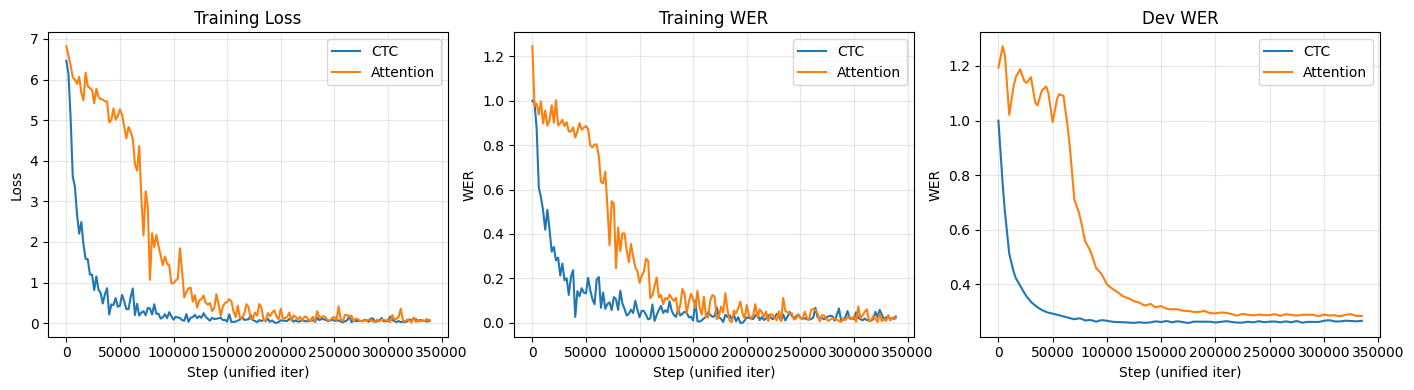

In [10]:
# 可视化：同一 iter 下的 Loss / WER
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1) Training Loss (统一 iter)
ax = axes[0]
for key in ['loss_ctc', 'loss_att']:
    if key in loss_unified:
        s, v = loss_unified[key]
        label = 'CTC' if key == 'loss_ctc' else 'Attention'
        ax.plot(s, v, label=label)
ax.set_xlabel('Step (unified iter)')
ax.set_ylabel('Loss')
ax.set_title('Training Loss')
ax.legend()
ax.grid(True, alpha=0.3)

# 2) Training WER (统一 iter)
ax = axes[1]
for key in ['wer_tr_ctc', 'wer_tr_att']:
    if key in wer_tr_unified:
        s, v = wer_tr_unified[key]
        label = 'CTC' if key == 'wer_tr_ctc' else 'Attention'
        ax.plot(s, v, label=label)
ax.set_xlabel('Step (unified iter)')
ax.set_ylabel('WER')
ax.set_title('Training WER')
ax.legend()
ax.grid(True, alpha=0.3)

# 3) Dev WER (统一 iter)
ax = axes[2]
for key in ['wer_dv_ctc', 'wer_dv_att']:
    if key in wer_dv_unified:
        s, v = wer_dv_unified[key]
        label = 'CTC' if key == 'wer_dv_ctc' else 'Attention'
        ax.plot(s, v, label=label)
ax.set_xlabel('Step (unified iter)')
ax.set_ylabel('WER')
ax.set_title('Dev WER')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
# 可选：保存统一后的数据到 CSV，方便别处用
out_dir = LOG_DIR
def save_unified(name, unified_dict):
    rows = []
    keys = sorted(unified_dict.keys())
    steps = unified_dict[keys[0]][0]
    for i, step in enumerate(steps):
        row = {'step': step}
        for k in keys:
            row[k] = unified_dict[k][1][i]
        rows.append(row)
    df = pd.DataFrame(rows)
    path = os.path.join(out_dir, name)
    df.to_csv(path, index=False)
    print('Saved', path)

save_unified('unified_loss.csv', loss_unified)
save_unified('unified_wer_tr.csv', wer_tr_unified)
save_unified('unified_wer_dv.csv', wer_dv_unified)

Saved ./unified_loss.csv
Saved ./unified_wer_tr.csv
Saved ./unified_wer_dv.csv
